Shortly, what i want to implement with this code is a gemmav4 which as released in 2 april 2026 and I want use it to annotated the rest of my rows from car advertisments dataset.
I did this architecture :

1. `teacher` model proposes labels
2. `verifier` model checks the proposal
3. `router` decides `accept`, `send_to_review`, or `ask_human`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

PROJECT_ROOT = "/content/drive/MyDrive/Gliner-Work.Dauphine"

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)



Mounted at /content/drive


Data loading

In [ ]:
from pathlib import Path


root = Path("/Users/raresolteanu/Desktop/Gliner-Work.Dauphine")
DATASET_PATH = root / "/content/annotation_working_master_human_2100_seed.csv"
OUTPUT_DIR = root / "gemma_review_pipeline" / "outputs"

TEXT_COLUMNS = [
    "Script",
    "Incrustation",
    "Visuel",
    "Titre",
    "MotsClés",
    "Thème",
    "Signature",
]

METADATA_COLUMNS = [
    "year",
    "Month",
    "Marque",
    "Produit",
    "Variété",
    "Electric",
    "Hybrid",
    "Support",
    "Format",
    "Agence",
    "length",
]

VALID_LABELS = [
    "Comfort/Practicality",
    "Design/Emotion",
    "Ecology/Sustainability",
    "Electrification",
    "Innovation/Technology",
    "Luxury/Status",
    "Performance",
    "Price/Value",
    "Safety/Reliability",
]

ROUTER_ACCEPT_THRESHOLD = 0.78
ROUTER_REVIEW_THRESHOLD = 0.55
ROUTER_HUMAN_THRESHOLD = 0.35

#GEMMA_MODEL_ID= "google/gemma-4-E2B-it" #If you run it locally, I suggest run thism if the data is over 1000 to avoid kernel crash, but it has the problem with weakest reasoning and weakest label accuracy
#GEMMA_MODEL_ID= "google/gemma-4-E4B-it" #balance of speed and quality, easier to fine-tune, it can work on better laptops
#GEMMA_MODEL_ID = "google/gemma-4-26B-A4B-it" #speed/quality tradeoff, MoE model with only about 3.8B active parameters at inference, but memory pressure
GEMMA_MODEL_ID = "google/gemma-4-31B-it" #best quality, strongest reasoning, best for maximum performance, but slowest, heaviest, most expensive,


imports for the next code

In [ ]:
from typing import Iterable
import pandas as pd

from gemma_review_pipeline.heuristics import pick_top_two, score_labels
from gemma_review_pipeline.schemas import (
    AnnotationPrediction,
    RouterDecision,
    VerifierDecision,
)

Firstly, we implemet a normalise function

In [ ]:
def normalize_text(value: object) -> str: #here we take any value kind and we return string
    if pd.isna(value): #here we check if there is any missing value, such as NaN or None
        return "" #if the value is missing it returns a empthy string
    return " ".join(str(value).split()).strip() # the values is transformed into string, than it breaks into words and remove spaces and then it put all together again and we remove the spaces from the beginning and end


then we load the rows

In [ ]:
def load_rows(limit: int | None = None, review_status: str = "needs_label") -> pd.DataFrame: # we return a dataframe and two optional inputs the limit and review_status, default being needs_label
    df = pd.read_csv(DATASET_PATH)
    if review_status:
        df = df[df["Review_Status"] == review_status].copy() #keeps where the rows match Review_Status and copy is to avoid pandas warning
    df["row_id"] = pd.to_numeric(df["row_id"], errors="coerce").astype("Int64") # we clean the row_id and we change the invalid values to NaN and Int64 to not allow missing values
    if limit is not None:
        df = df.head(limit).copy()
    return df

We build here the build record text function

In [ ]:
def build_record_text(row: pd.Series, columns: Iterable[str] | None = None) -> str: #it takes one row df a list of columns to the return
    columns = list(columns or TEXT_COLUMNS)# use columns if provided if not use TEXT_COLUMNS
    parts: list[str] = [] #create an empthy list
    for column in columns:
        text = normalize_text(row.get(column, ""))# get the value if the column existsm otherwise empthy string and clean it
        if text:
            parts.append(f"{column}: {text}")# add the column name and its text
    return "\n".join(parts) # join all of it in one string separated by line breaks

then we build also the meta data function for text this is the exact same function, but it is for METADATA_COLUMNS

In [ ]:
def build_metadata_text(row: pd.Series, columns: Iterable[str] | None = None) -> str:
    columns = list(columns or METADATA_COLUMNS)
    parts: list[str] = []
    for column in columns:
        text = normalize_text(row.get(column, ""))
        if text:
            parts.append(f"{column}: {text}")
    return "\n".join(parts)

 First annotator, which is a dummy teacher.( it return JSON with:
- main_benefit
- secondary_benefit
- confidence
- alt_label
- reason)



The used labels
Valid labels:
Comfort/Practicality, Design/Emotion, Ecology/Sustainability, Electrification,
Innovation/Technology, Luxury/Status, Performance, Price/Value, Safety/Reliability


The function for the teacher prompt

In [ ]:
def build_teacher_prompt(row: pd.Series) -> str: #transform the row into pandas and then it turn it in string
    return f"""You are an annotation model for automotive ads.

Metadata:
{build_metadata_text(row)}

Content:
{build_record_text(row)}
"""



the anotation prediction function

In [ ]:
def dummy_teacher_predict(row: pd.Series) -> AnnotationPrediction: #takes one row  from df and transform it into a annotation
    text = build_record_text(row) #combines Script, Incrustation etc. into strings
    metadata = {key: row.get(key) for key in row.index} # a dict with all values from rows, this is used to so score fun can look at metadata
    scores = score_labels(text, metadata) # this give to the score fun the text and metadata and it return a score for each label possible
    top, second = pick_top_two(scores) # select the top 2 labels
    total = sum(max(value, 0.0) for value in scores.values()) or 1.0 #add all pos values and prevents neg from reducing the total and or 1 is to avoid the division by 0
    confidence = min(0.95, max(0.2, top[1] / total + 0.35)) #cofidence scorem it measures how strong the label is compared with others and with min we make sure the confi not too high and wth max not too low
    secondary = second[0] if second[0] and second[0] != top[0] else "" # this choose the second label as secondary_benefit, if it exists and is not like the previous one, otherwise it leaves it empty
    reason = f"keyword score main={top[0]}:{top[1]:.1f}; alt={second[0]}:{second[1]:.1f}"
    return AnnotationPrediction(
        row_id=int(row["row_id"]), #rows id as int
        main_benefit=top[0],
        secondary_benefit=secondary,
        confidence=round(confidence, 4), #save confidence rounded to 4 deci
        alt_label=second[0], #the alt label
        reason=reason, #as str
        model_name="dummy_teacher", # prediction came from teh teacher
    )

How many rows to annotate function

In [ ]:
def annotate_rows(limit: int = 20) -> pd.DataFrame: #a fun for how many rows to annotate, default is 20
    rows = load_rows(limit=limit, review_status="needs_label") #load the CSV an donly keeps rows where Review_Status == "needs_label"
    predictions = [dummy_teacher_predict(row).to_dict() for _, row in rows.iterrows()] #it loops through every rowws and makes a pred and convert it in dictm the first '_' is row index
    return pd.DataFrame(predictions)

In [ ]:
def main() -> None: #the entry point of a script and it return None
    parser = argparse.ArgumentParser() #create an argument parser, this is used with scope of running it from terminal and pass options
    parser.add_argument("--limit", type=int, default=20) #adds one optional arg limit, it needs to be int and the default is 20
    args = parser.parse_args() #reads the arg and stores them in args

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True) #creates a output folderm create missing parent folders and do not crash if it already exists
    output_path = OUTPUT_DIR / "teacher_predictions.csv" # a full path
    predictions = annotate_rows(limit=args.limit) # runs theannotate_rows() fun on how many rows are req
    predictions.to_csv(output_path, index=False)# save df to csv file and it does not save row nr
    print("teacher model id placeholder:", GEMMA_MODEL_ID) #model id
    print("wrote", output_path) #where the file is saved
    print(predictions.head().to_string(index=False)) #first few rows


  Second model, it uses a narrower evidence slice.

In [ ]:
def verifier_predict(row: pd.Series, teacher_main: str) -> VerifierDecision: # takes a row and the main label proposed by teacher and it returns a VerifierDecision
    text = "\n".join(
        part
        for part in [
            str(row.get("Incrustation", "")),
            str(row.get("Visuel", "")),
            str(row.get("Titre", ""))
        ] #gets the values and transform them in stringsm only these columnsm since verifier is using a narrower evidence than teacher
        if part and part != "nan"
    ) #keeps only non-empty or remove it
    #the rest of the function uses the same codes as beforem but adapted to the Verifier and a little finetuned
    metadata = {key: row.get(key) for key in row.index}
    scores = score_labels(text, metadata)
    top, second = pick_top_two(scores)
    total = sum(max(value, 0.0) for value in scores.values()) or 1.0
    confidence = min(0.95, max(0.15, top[1] / total + 0.25))
    agrees = top[0] == teacher_main #this is verifies it to be equal with the teacher prediction
    reason = "agreement" if agrees else f"teacher={teacher_main}, verifier={top[0]}, alt={second[0]}"
    return VerifierDecision(
        row_id=int(row["row_id"]), #row id
        verifier_main_benefit=top[0],
        verifier_confidence=round(confidence, 4),
        agrees_with_teacher=agrees, #stores if it agrees with teacher or not
        disagreement_reason=reason, # explanation for the above
    )


In [ ]:
def run_verifier(limit: int = 20) -> pd.DataFrame:
    rows = load_rows(limit=limit, review_status="needs_label")
    teacher = pd.read_csv(OUTPUT_DIR / "teacher_predictions.csv") #load teh teacher predictions
    merged = rows.merge(teacher[["row_id", "main_benefit"]], on="row_id", how="inner") #Combines the original dataset rows with the teacher predictions
    decisions = [
        verifier_predict(row, row["main_benefit"]).to_dict() #the second arg is the teacher label for the same row
        for _, row in merged.iterrows()
    ]
    return pd.DataFrame(decisions)

The same function as in the teacher, but adapted to this

In [ ]:
def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--limit", type=int, default=20)
    args = parser.parse_args()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = OUTPUT_DIR / "verifier_decisions.csv"
    decisions = run_verifier(limit=args.limit)
    decisions.to_csv(output_path, index=False)
    print("wrote", output_path)
    print(decisions.head().to_string(index=False))

   this model decides whether to accept, review, or ask a human.

In [ ]:
def route_row(row: pd.Series) -> RouterDecision:#takes one row and gives a RouterDecision object.
    teacher_conf = float(row["confidence"]) #reads the teacher confi and make it float
    verifier_conf = float(row["verifier_confidence"]) #the same but for verifier
    agrees = bool(row["agrees_with_teacher"]) #check if the two agrees with eachother
    route_score = (teacher_conf + verifier_conf) / 2.0 #computes the avg confi between the two, an overall routing score
 # first decison rule if teacher and veriefier agree and both teacher and verifier confi exced the treshold, then trust the predi
    if agrees and teacher_conf >= ROUTER_ACCEPT_THRESHOLD and verifier_conf >= ROUTER_REVIEW_THRESHOLD:
        action = "accept" #mark the row as accepted automatically
        reason = "teacher and verifier agree with strong confidence" #explanation
#second decision rule if teacher and verifier disagree and the average score is low and teacher confi low the the row is risky
    elif (not agrees and route_score < ROUTER_REVIEW_THRESHOLD) or teacher_conf <= ROUTER_HUMAN_THRESHOLD:
        action = "ask_human" #what the model should do
        reason = "low confidence or verifier disagreement" #explanation
#third decision rule if the row is not clearly safe and not clearly bad, it is in the middle.
    else:
        action = "send_to_review" #what the model should do
        reason = "uncertain case worth a second pass" # explanation

    return RouterDecision(
        row_id=int(row["row_id"]), #save row id
        route_action=action, #save the chosen action
        route_score=round(route_score, 4), #save the avg confi
        route_reason=reason, #save the explanation
    )

In [ ]:
def run_router() -> pd.DataFrame:
    teacher = pd.read_csv(OUTPUT_DIR / "teacher_predictions.csv")
    verifier = pd.read_csv(OUTPUT_DIR / "verifier_decisions.csv")
    merged = teacher.merge(verifier, on="row_id", how="inner")
    actions = [route_row(row).to_dict() for _, row in merged.iterrows()]
    return pd.DataFrame(actions)

In [ ]:
def main() -> None:
    parser = argparse.ArgumentParser()
    parser.parse_args()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = OUTPUT_DIR / "router_actions.csv"
    actions = run_router()
    actions.to_csv(output_path, index=False)
    print("wrote", output_path)
    print(actions["route_action"].value_counts().to_string())

  We do a check with a small sample.


In [ ]:
def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--limit", type=int, default=20)
    args = parser.parse_args()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    teacher = annotate_rows(limit=args.limit)
    teacher.to_csv(OUTPUT_DIR / "teacher_predictions.csv", index=False)

    verifier = run_verifier(limit=args.limit)
    verifier.to_csv(OUTPUT_DIR / "verifier_decisions.csv", index=False)

    router = run_router()
    router.to_csv(OUTPUT_DIR / "router_actions.csv", index=False)

    print("demo complete")
    print("teacher rows:", len(teacher))
    print("verifier rows:", len(verifier))
    print("router rows:", len(router))
    print(router.head().to_string(index=False))


In [ ]:
limit = 20

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

teacher = annotate_rows(limit=limit)
teacher.to_csv(OUTPUT_DIR / "teacher_predictions.csv", index=False)

verifier = run_verifier(limit=limit)
verifier.to_csv(OUTPUT_DIR / "verifier_decisions.csv", index=False)

router = run_router()
router.to_csv(OUTPUT_DIR / "router_actions.csv", index=False)

print("demo complete")
print(router.head().to_string(index=False))


demo complete
 row_id   route_action  route_score                                      route_reason
   2100 send_to_review       0.8143                uncertain case worth a second pass
   2101 send_to_review       0.7040                uncertain case worth a second pass
   2102         accept       0.9500 teacher and verifier agree with strong confidence
   2103         accept       0.8357 teacher and verifier agree with strong confidence
   2104         accept       0.7722 teacher and verifier agree with strong confidence


the code to run the annotation for all the rows

In [ ]:
remaining_rows = load_rows(limit=None, review_status="needs_label") #without the limit as before
remaining_count = len(remaining_rows) #counter

print("remaining rows to annotate:", remaining_count) #to see how many we still have to annotate

OUTPUT_DIR.mkdir(parents=True, exist_ok=True) #make sure it exists

teacher_path = OUTPUT_DIR / "teacher_predictions.csv" #path were teacher predi are saved
verifier_path = OUTPUT_DIR / "verifier_decisions.csv"#path were verifier predi are saved
router_path = OUTPUT_DIR / "router_actions.csv" # path were router predi are saved
final_path = OUTPUT_DIR / "annotation_working_master_with_new_labels.csv"


#this three let teacher verifier and the router run only on the remaining rows
teacher = annotate_rows(limit=remaining_count)
teacher.to_csv(teacher_path, index=False)

verifier = run_verifier(limit=remaining_count)
verifier.to_csv(verifier_path, index=False)

router = run_router()
router.to_csv(router_path, index=False)

full_df = pd.read_csv(DATASET_PATH) #load the complete dataset

#these three lines help us clean the code
full_df["row_id"] = pd.to_numeric(full_df["row_id"], errors="coerce").astype("Int64")
teacher["row_id"] = pd.to_numeric(teacher["row_id"], errors="coerce").astype("Int64")
router["row_id"] = pd.to_numeric(router["row_id"], errors="coerce").astype("Int64")
 #mearge the full dataset with tecaher outputs
merged = full_df.merge(
    teacher[
        [
            "row_id",
            "main_benefit",
            "secondary_benefit",
            "confidence",
            "alt_label",
            "reason",
            "model_name",
        ]
    ],
    on="row_id",
    how="left",
)
#adds the router to the merged table
merged = merged.merge(
    router[["row_id", "route_action", "route_score", "route_reason"]],
    on="row_id",
    how="left",
)

needs_label_mask = merged["Review_Status"] == "needs_label" #rows that needed to be  annotated
merged.loc[needs_label_mask, "Main_Benefit"] = merged.loc[needs_label_mask, "main_benefit"]
merged.loc[needs_label_mask, "Secondary_Benefit"] = merged.loc[needs_label_mask, "secondary_benefit"]

merged.to_csv(final_path, index=False)

print("done")
print("teacher rows:", len(teacher))
print("verifier rows:", len(verifier))
print("router rows:", len(router))
print(router["route_action"].value_counts().to_string()) #count how many rows were annotated with each label
print("saved:")
#where were all the output files saved
print("-", teacher_path)
print("-", verifier_path)
print("-", router_path)
print("-", final_path)


remaining rows to annotate: 6838
done
teacher rows: 6838
verifier rows: 6838
router rows: 6838
route_action
accept            4675
send_to_review    2160
ask_human            3
saved:
- /Users/raresolteanu/Desktop/Gliner-Work.Dauphine/gemma_review_pipeline/outputs/teacher_predictions.csv
- /Users/raresolteanu/Desktop/Gliner-Work.Dauphine/gemma_review_pipeline/outputs/verifier_decisions.csv
- /Users/raresolteanu/Desktop/Gliner-Work.Dauphine/gemma_review_pipeline/outputs/router_actions.csv
- /Users/raresolteanu/Desktop/Gliner-Work.Dauphine/gemma_review_pipeline/outputs/annotation_working_master_with_new_labels.csv


what i want to do is to count every label based on each router type

In [ ]:
#load the data
teacher = pd.read_csv(teacher_path)
router = pd.read_csv(router_path)
#clean them
teacher["row_id"] = pd.to_numeric(teacher["row_id"], errors="coerce").astype("Int64")
router["row_id"] = pd.to_numeric(router["row_id"], errors="coerce").astype("Int64")
 #combines teacher and router table into one
router_labels = teacher.merge(
    router[["row_id", "route_action", "route_score", "route_reason"]],
    on="row_id",
    how="inner",
)
#a summary for main benefit
main_counts = (
    router_labels
    .groupby(["route_action", "main_benefit"])
    .size()#count how many rows are per group
    .reset_index(name="count")
    .sort_values(["route_action", "count"], ascending=[True, False])
)
#the same, but for secondarym only when is not empty
secondary_counts = (
    router_labels[router_labels["secondary_benefit"].fillna("") != ""]
    .groupby(["route_action", "secondary_benefit"])
    .size() #count how many rows are per group
    .reset_index(name="count")
    .sort_values(["route_action", "count"], ascending=[True, False])
)
#build a pivot table
main_pivot = (
    router_labels
    .pivot_table(
        index="route_action",
        columns="main_benefit",
        aggfunc="size",
        fill_value=0,
    )
)
#the same, but for secondary
secondary_pivot = (
    router_labels[router_labels["secondary_benefit"].fillna("") != ""]
    .pivot_table(
        index="route_action",
        columns="secondary_benefit",
        aggfunc="size",
        fill_value=0,
    )
)

print("Main benefit counts by router action")
print(main_counts.to_string(index=False))

print("\nMain benefit pivot table")
print(main_pivot.to_string())

print("\nSecondary benefit counts by router action")
print(secondary_counts.to_string(index=False))

print("\nSecondary benefit pivot table")
print(secondary_pivot.to_string())


Main benefit counts by router action
  route_action           main_benefit  count
        accept        Electrification   2648
        accept            Price/Value   1733
        accept  Innovation/Technology    131
        accept          Luxury/Status     67
        accept            Performance     48
        accept   Comfort/Practicality     19
        accept         Design/Emotion     17
        accept     Safety/Reliability      8
        accept Ecology/Sustainability      4
     ask_human  Innovation/Technology      2
     ask_human            Price/Value      1
send_to_review            Price/Value    901
send_to_review        Electrification    701
send_to_review         Design/Emotion    246
send_to_review  Innovation/Technology    171
send_to_review          Luxury/Status     62
send_to_review            Performance     61
send_to_review   Comfort/Practicality     10
send_to_review     Safety/Reliability      8

Main benefit pivot table
main_benefit    Comfort/Practicality 

if you want to save them

In [ ]:
main_counts.to_csv(OUTPUT_DIR / "main_benefit_counts_by_router_action.csv", index=False)
secondary_counts.to_csv(OUTPUT_DIR / "secondary_benefit_counts_by_router_action.csv", index=False)
main_pivot.to_csv(OUTPUT_DIR / "main_benefit_pivot_by_router_action.csv")
secondary_pivot.to_csv(OUTPUT_DIR / "secondary_benefit_pivot_by_router_action.csv")


plot for main benefit

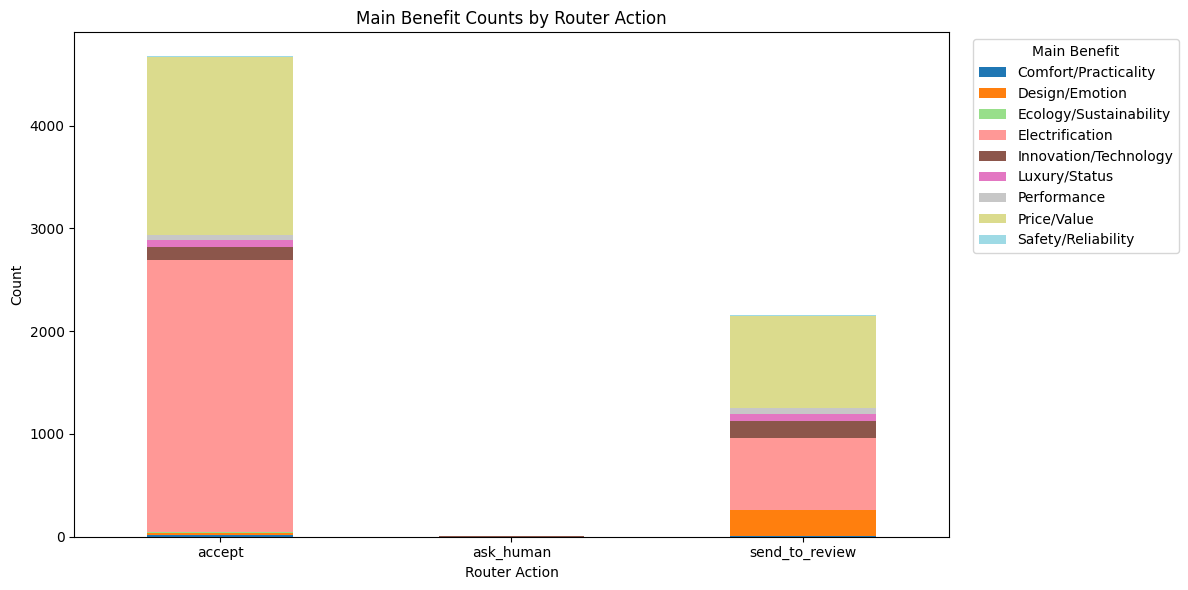

In [ ]:
import matplotlib.pyplot as plt

ax = main_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
)

ax.set_title("Main Benefit Counts by Router Action")
ax.set_xlabel("Router Action")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Main Benefit", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


for the secondary

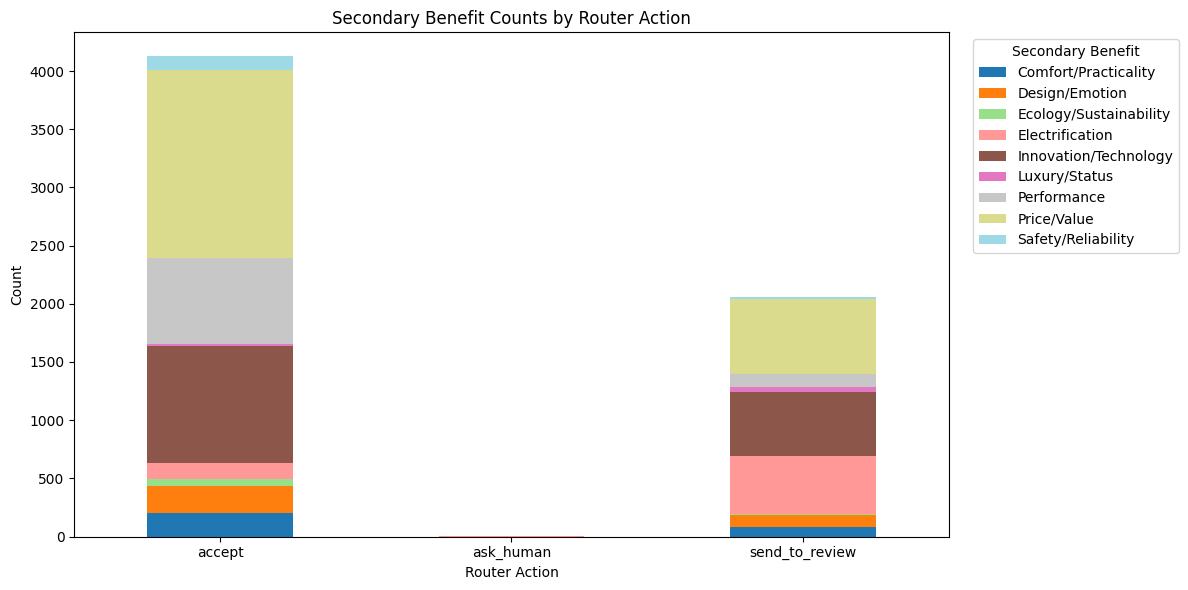

In [ ]:
ax = secondary_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab20",
)

ax.set_title("Secondary Benefit Counts by Router Action")
ax.set_xlabel("Router Action")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Secondary Benefit", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


a heatmap for main

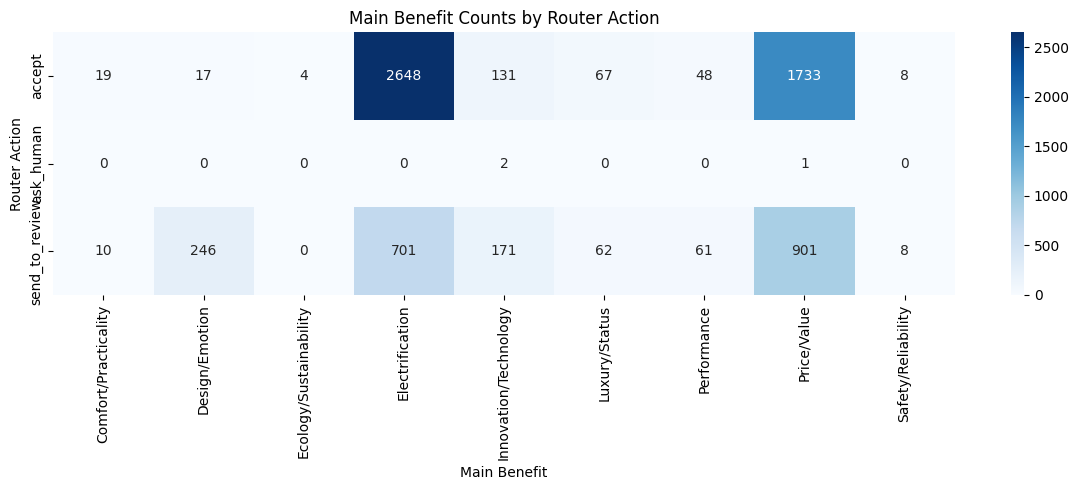

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(main_pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Main Benefit Counts by Router Action")
plt.xlabel("Main Benefit")
plt.ylabel("Router Action")
plt.tight_layout()
plt.show()


In [ ]:
#load data
full_df = pd.read_csv(DATASET_PATH)
teacher = pd.read_csv(teacher_path)
router = pd.read_csv(router_path)
#clean it
full_df["row_id"] = pd.to_numeric(full_df["row_id"], errors="coerce").astype("Int64")
teacher["row_id"] = pd.to_numeric(teacher["row_id"], errors="coerce").astype("Int64")
router["row_id"] = pd.to_numeric(router["row_id"], errors="coerce").astype("Int64")


counter per year, differnet bar plot based on router decision


accept - entries by year
 year  entries
 2017      265
 2018      437
 2019      462
 2020      412
 2021      340
 2022      643
 2023     1048
 2024     1068


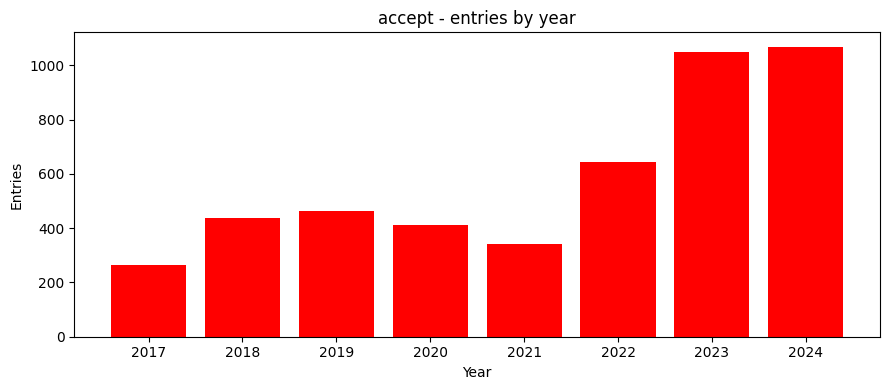


ask_human - entries by year
 year  entries
 2018        1
 2023        2


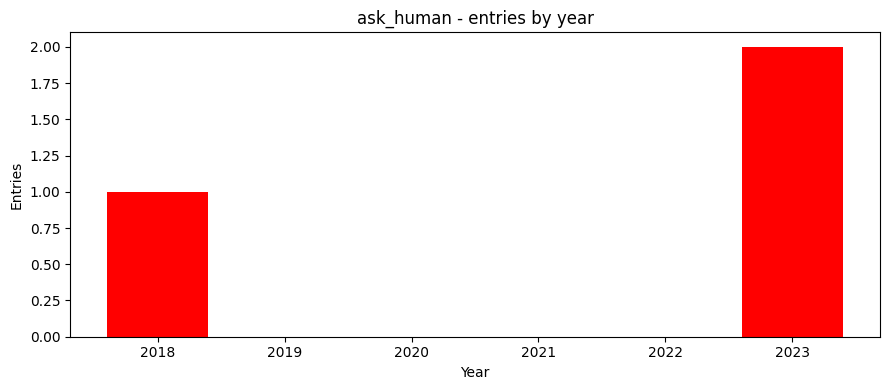


send_to_review - entries by year
 year  entries
 2017      159
 2018      287
 2019      266
 2020      159
 2021      159
 2022      289
 2023      424
 2024      417


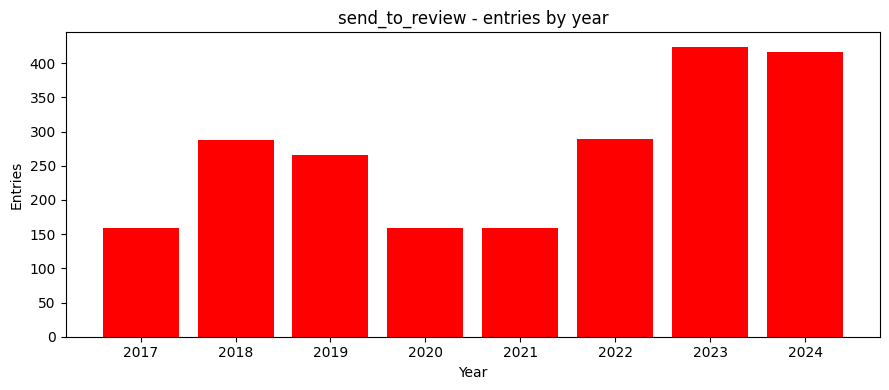

In [ ]:
# we merge id year with teacher predi
plot_df = full_df[["row_id", "year"]].merge(
    teacher[["row_id", "main_benefit"]],
    on="row_id",
    how="inner",
)
#adds the router infor
plot_df = plot_df.merge(
    router[["row_id", "route_action"]],
    on="row_id",
    how="inner",
)

plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce") #converts year into numeric and if the values is missing it transform it in NaN
plot_df = plot_df.dropna(subset=["year", "main_benefit", "route_action"]).copy() #removes row where year,main_benefit,route_action not exist
plot_df["year"] = plot_df["year"].astype(int)

route_actions = sorted(plot_df["route_action"].unique()) #get all unique router output sort them

for route in route_actions:
    route_df = plot_df[plot_df["route_action"] == route].copy() #keeps only router actionof the current action
#a table with the counter
    year_counts = (
        route_df.groupby("year") #group it per year
        .size()#count them
        .reset_index(name="entries")
        .sort_values("year") #sort them
    )

    print(f"\n{route} - entries by year")
    print(year_counts.to_string(index=False)) #yearly counts table

    plt.figure(figsize=(9, 4))
    plt.bar(year_counts["year"], year_counts["entries"], color="red")
    plt.title(f"{route} - entries by year")
    plt.xlabel("Year")
    plt.ylabel("Entries")
    plt.tight_layout()
    plt.show()

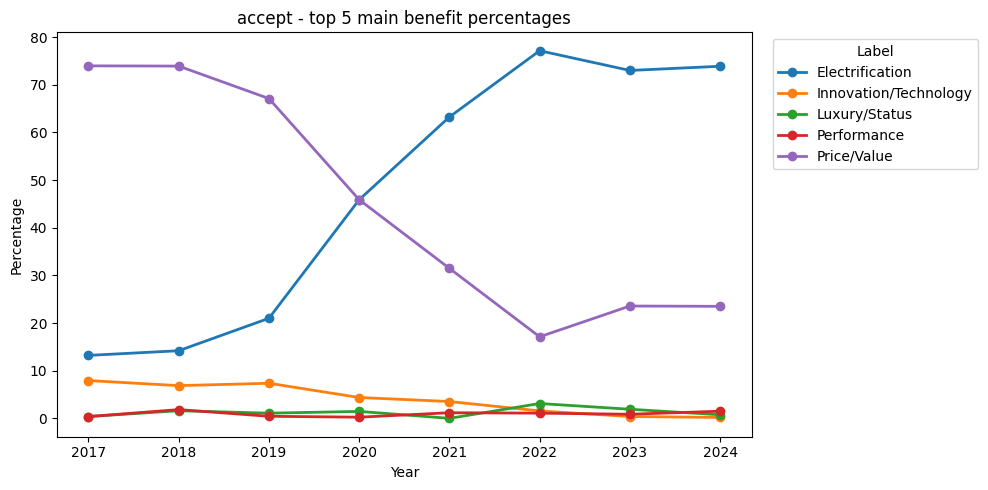

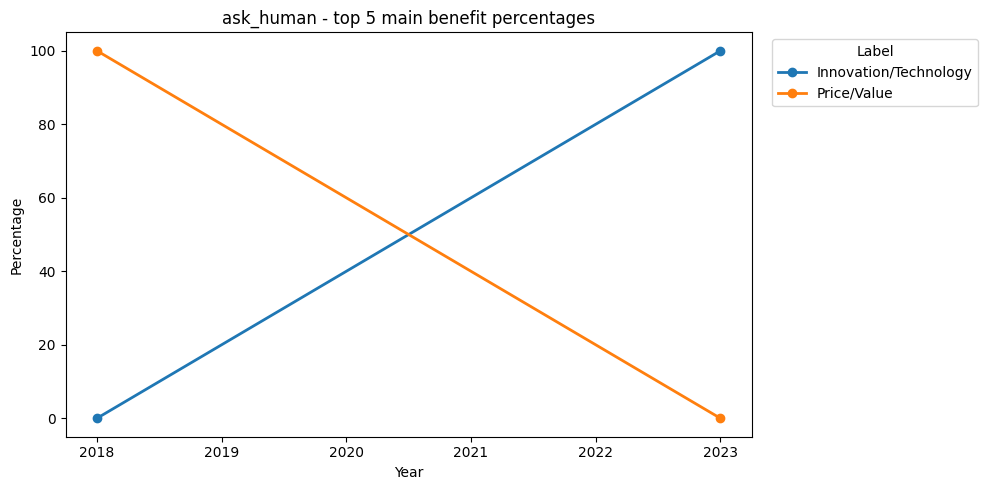

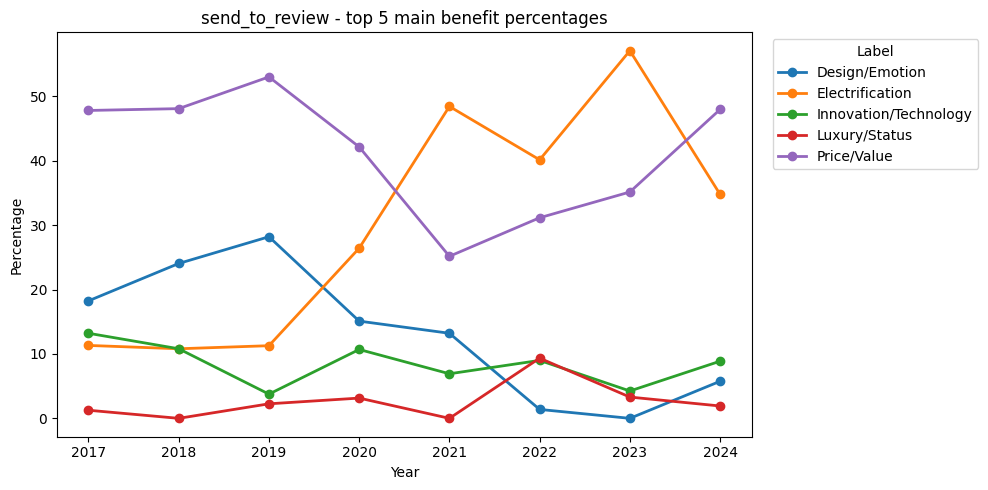

In [ ]:
for route in route_actions: # a loop for each router output
    route_df = plot_df[plot_df["route_action"] == route].copy() #keeps only the rows where it matches with current route
#count each main benefit label  within each year
    label_counts = (
        route_df.groupby(["year", "main_benefit"])
        .size()
        .reset_index(name="count")
    )

    label_counts = label_counts.merge(year_counts, on="year", how="left")#Adds the total number of entries per year
    label_counts["percentage"] = 100 * label_counts["count"] / label_counts["entries"] #make them percentages
#this finds the top 5
    top_labels = (
        route_df["main_benefit"]
        .value_counts()
        .head(5)
        .index
    )
#keeps only them
    plot_counts = label_counts[label_counts["main_benefit"].isin(top_labels)].copy()
# from long table into a wide one
    pivot_pct = plot_counts.pivot(
        index="year",
        columns="main_benefit",
        values="percentage"
    ).fillna(0)

    pivot_pct = pivot_pct.sort_index()

    plt.figure(figsize=(10, 5))
#the lines for plot
    for label in pivot_pct.columns:
        plt.plot(
            pivot_pct.index,
            pivot_pct[label],
            marker="o",
            linewidth=2,
            label=label
        )

    plt.title(f"{route} - top 5 main benefit percentages")
    plt.xlabel("Year")
    plt.ylabel("Percentage")
    plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
